# 03｜训练第一个 CNN

现在把卷积层、激活函数、池化和分类头连接起来，观察模型怎样学习。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import quick_demo

## 基线结构

```text
[B, 1, H, W]
  → Conv2d(1, 8, 3, padding=1)
  → ReLU
  → MaxPool2d(2)
  → Conv2d(8, 16, 3, padding=1)
  → ReLU
  → Flatten
  → Linear(..., 10)
```

`H=W=8` 时池化后是 4×4；以后输入 28×28 时池化后是 14×14。模型根据 `image_size` 计算分类层输入，不把 8 写死在训练循环里。


CNN 配置对比
------------------------------------------------------------------------------
配置                           测试准确率       右移准确率         参数量       耗时(秒)
------------------------------------------------------------------------------
CNN｜通道 8→16｜max pooling      97.3%      65.8%       3,818        0.60
------------------------------------------------------------------------------


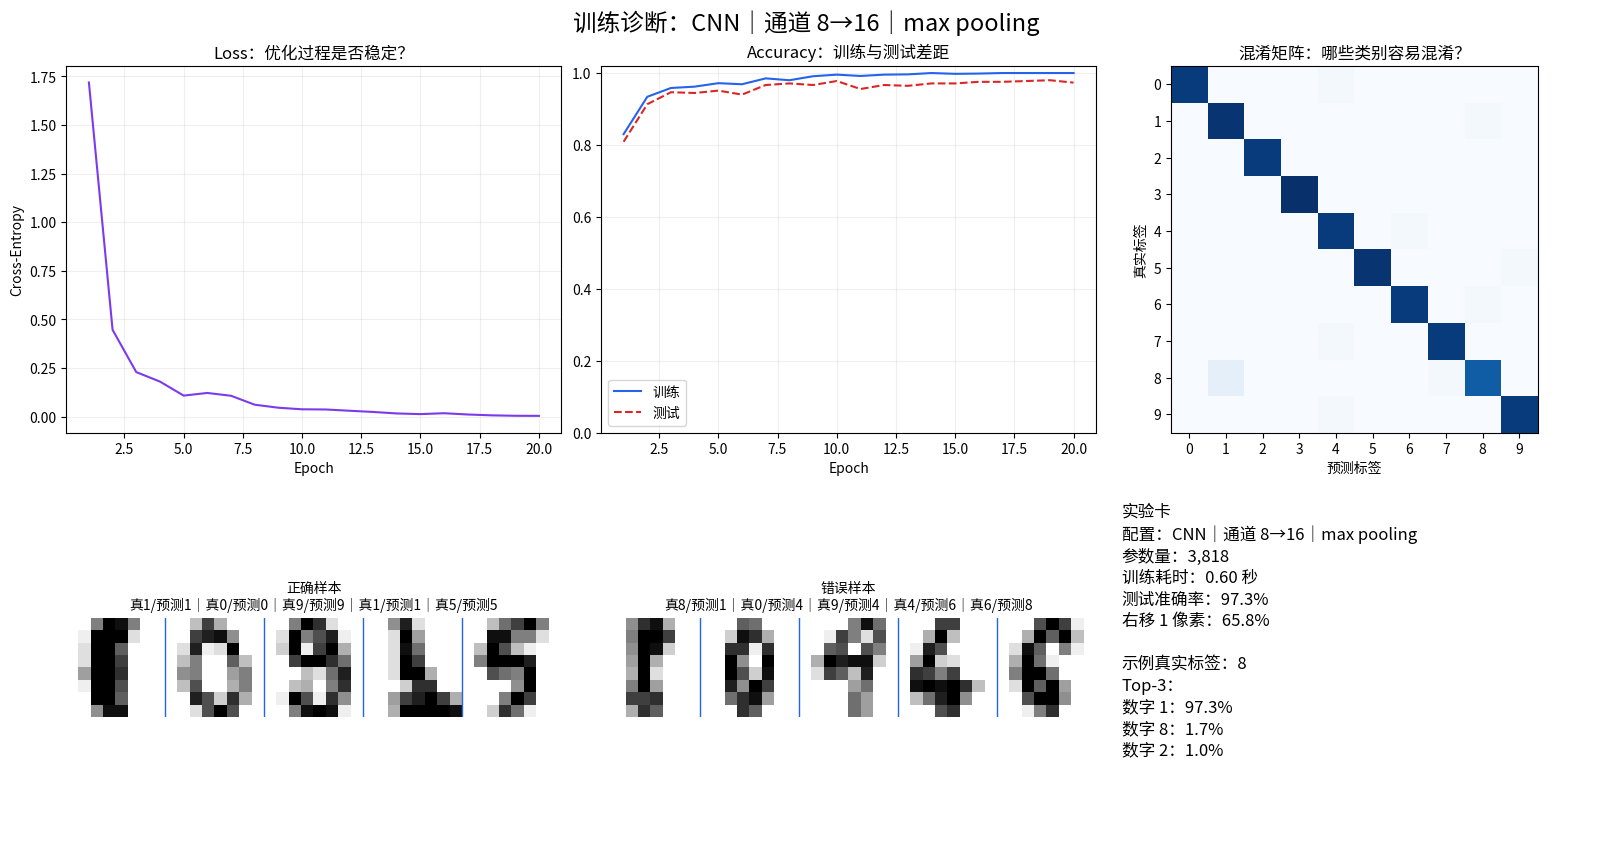

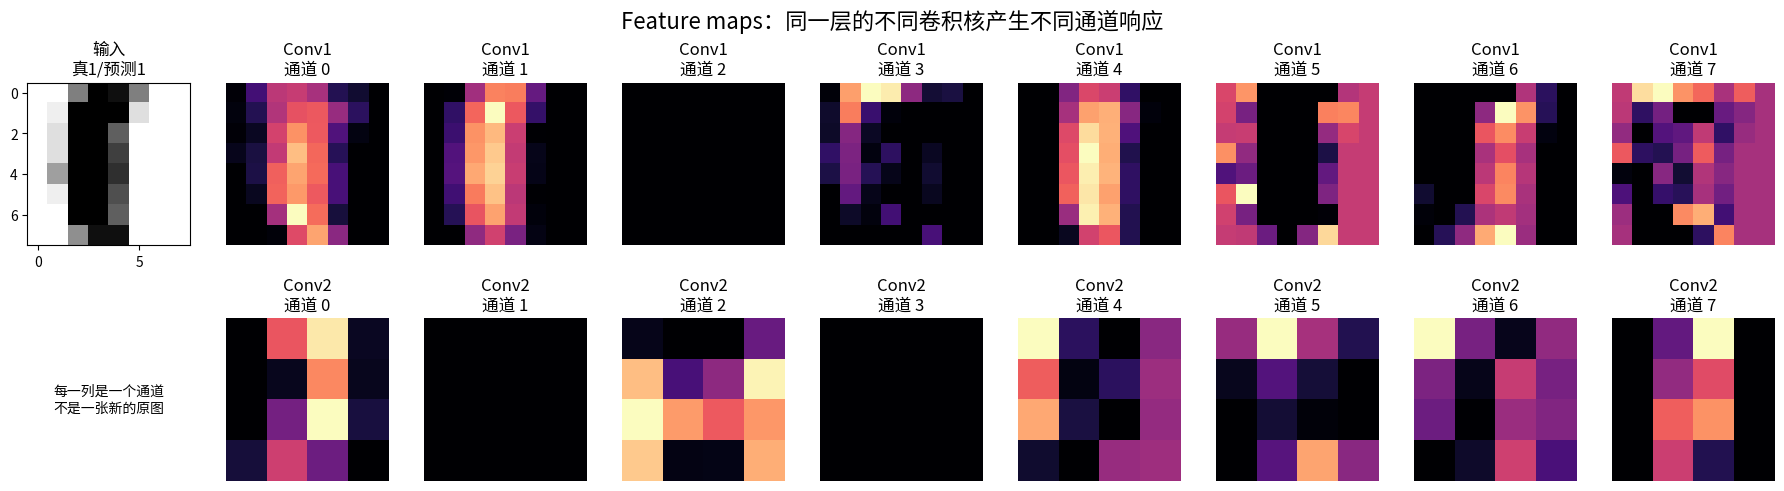

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

result = quick_demo(epochs=20, device=DEVICE, show_features=True)

In [3]:
print(result.model)
device = next(result.model.parameters()).device
sample = result.data.x_test[:2].to(device)
for name, tensor in result.model.feature_maps(sample).items():
    print(f"{name:10s} shape={tuple(tensor.shape)}")
print("logits shape：", tuple(result.model(sample).shape))

SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.0, inplace=False)
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
第一层卷积      shape=(2, 8, 8, 8)
池化后        shape=(2, 8, 4, 4)
第二层卷积      shape=(2, 16, 4, 4)
logits shape： (2, 10)


**观察重点：**第一层 Feature maps 保持 8×8，池化后变成 4×4，第二层通道数增加到 16。空间尺寸减小与通道数增加是两种不同变化。

Feature map 只显示某个通道对当前输入的响应，不能当作模型“思维过程”的完整证明。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [4]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……

{'status': 'ok', 'restart': False}